TASK 1: NAV Trend Analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('default')

%matplotlib inline

In [5]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

category = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

folio = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv"
)

transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

Chart 1

All 40 funds NAV trend

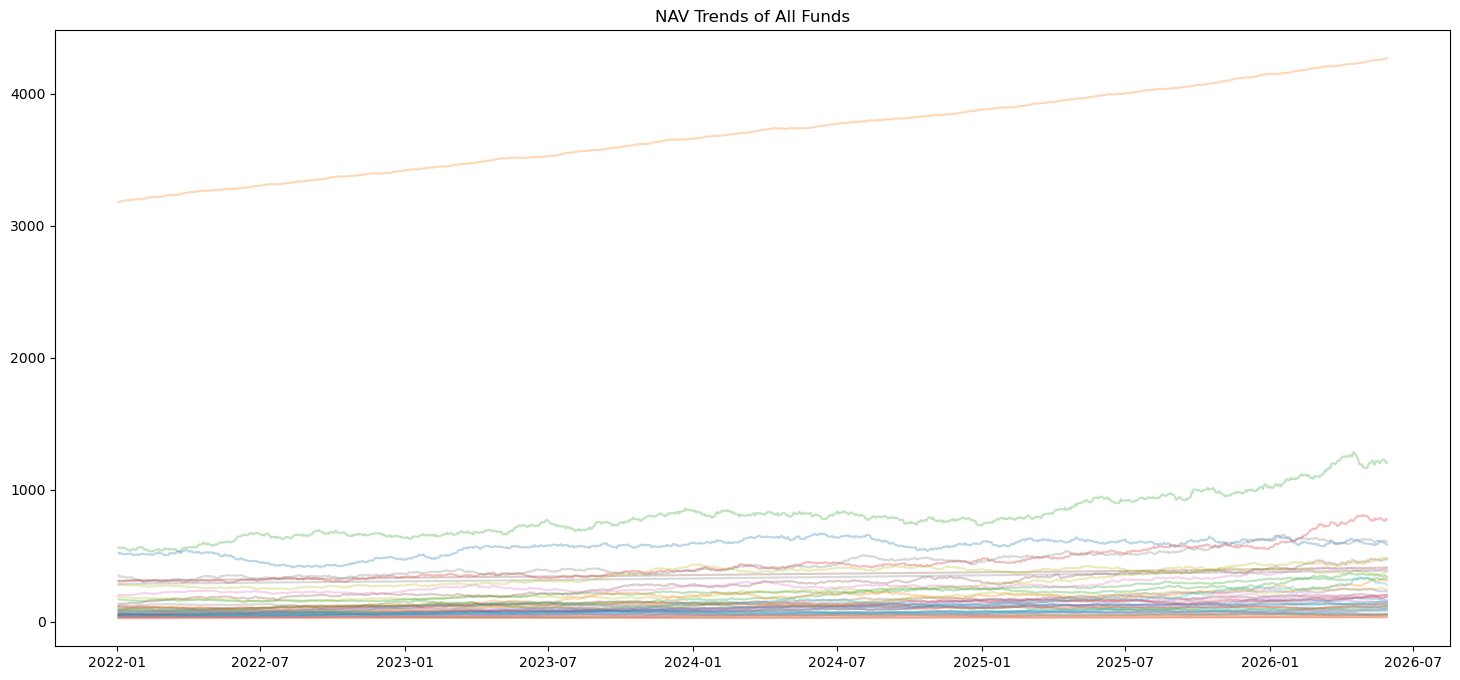

In [6]:
nav['date'] = pd.to_datetime(nav['date'])

plt.figure(figsize=(18,8))

for code in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        alpha=0.3
    )

plt.title("NAV Trends of All Funds")
plt.show()

Observations:
Most mutual fund schemes exhibit a long-term upward NAV trend between 2022 and 2026.
Fund performance varies significantly across schemes, indicating differences in investment strategies and risk profiles.
NAV growth accelerated during the 2023 market rally period.
Increased volatility can be observed during the 2024 correction phase.
Overall, the mutual fund industry demonstrates strong long-term wealth creation potential.

Chart 2

Top 5 funds comparison

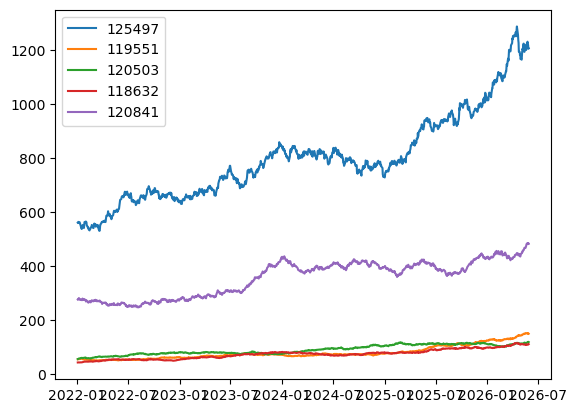

In [7]:
selected = [
    125497,
    119551,
    120503,
    118632,
    120841
]

for code in selected:

    temp = nav[
        nav['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=code
    )

plt.legend()
plt.show()

Observations:
Some funds consistently outperform others in terms of NAV appreciation.
The growth trajectories differ despite all funds belonging to similar categories.
Higher NAV growth may indicate superior portfolio management and stock selection.
Performance divergence becomes more visible after 2023.
Investors could use this comparison for benchmarking fund performance.

TASK 2: AUM Growth Analysis

Chart 3: AUM by Fund House

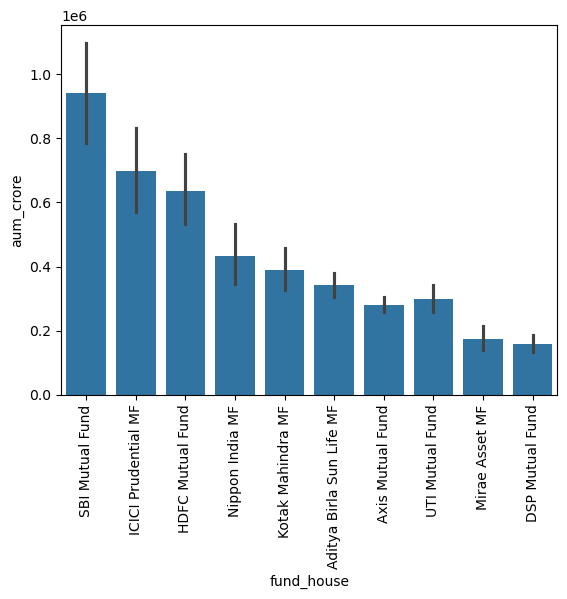

In [8]:
sns.barplot(
    data=aum,
    x='fund_house',
    y='aum_crore'
)

plt.xticks(rotation=90)
plt.show()

Observations
A few large AMCs dominate the Indian mutual fund industry.
The leading fund house manages significantly higher assets than its competitors.
AUM concentration indicates strong investor trust in established fund houses.
Smaller AMCs represent a comparatively small share of industry assets.
Market leadership remains concentrated among top players.

Chart 4

Year-wise AUM trend

In [10]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [13]:
aum['date'] = pd.to_datetime(
    aum['date'],
    errors='coerce'
)

In [15]:
aum['year'] = aum['date'].dt.year

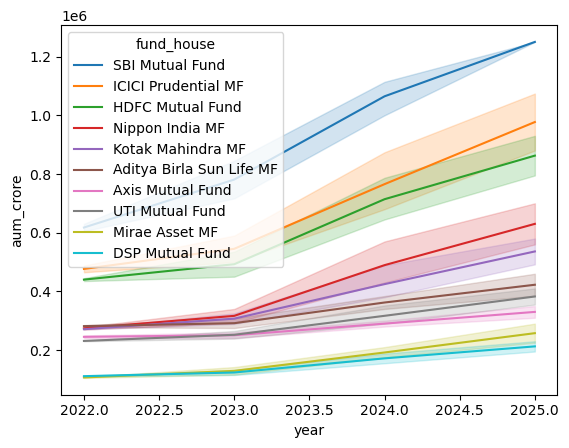

In [16]:
sns.lineplot(
    data=aum,
    x='year',
    y='aum_crore',
    hue='fund_house'
)

plt.show()

Observations:
Most fund houses show consistent AUM growth over time.
Industry-wide expansion indicates increasing investor participation.
Certain fund houses exhibit faster growth than peers.
AUM growth accelerated during bullish market periods.
Rising AUM reflects increasing confidence in mutual fund investments.

TASK 3: SIP Inflow Trend

Chart 5

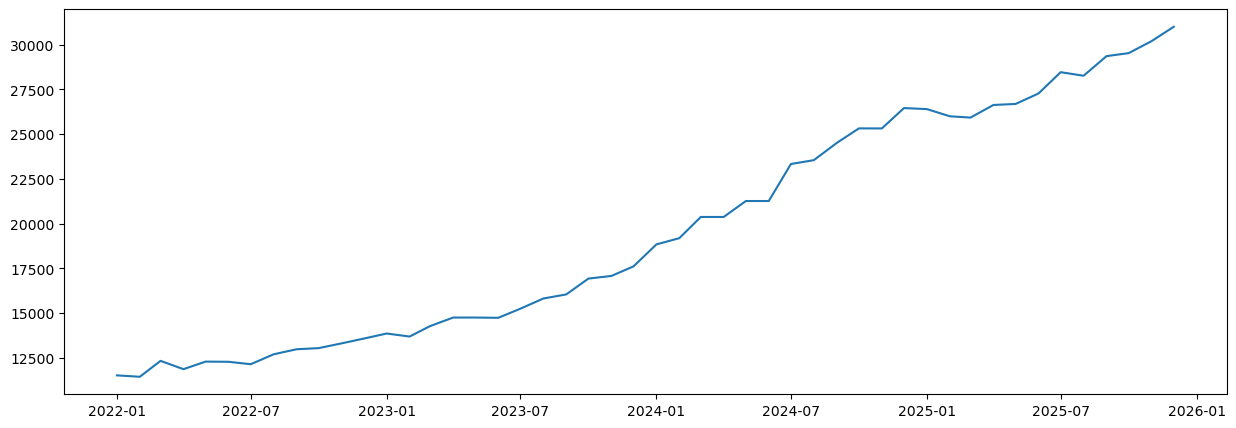

In [17]:
sip['month'] = pd.to_datetime(
    sip['month']
)

plt.figure(figsize=(15,5))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore']
)

plt.show()

Observations:
SIP inflows demonstrate a strong upward trend throughout the period.
Retail investor participation has steadily increased.
The highest SIP inflow was recorded toward the end of the dataset.
Temporary fluctuations do not significantly impact the overall growth trend.
SIP investing has become a preferred investment approach for Indian investors.

Chart 6

Active SIP Accounts

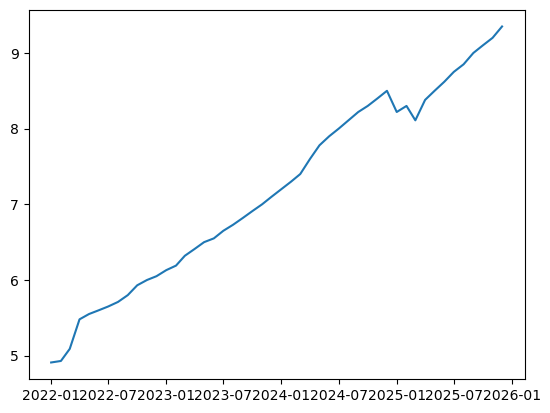

In [18]:
plt.plot(
    sip['month'],
    sip['active_sip_accounts_crore']
)

plt.show()

Observations:
The number of active SIP accounts has grown consistently.
Growth in SIP accounts indicates improving financial awareness.
Investor retention appears strong across the industry.
The rise in active accounts supports sustained SIP inflow growth.
Mutual funds continue to attract new retail investors.

TASK 4: Category-wise Inflow Heatmap

Chart 7: Category-wise Inflow Heatmap

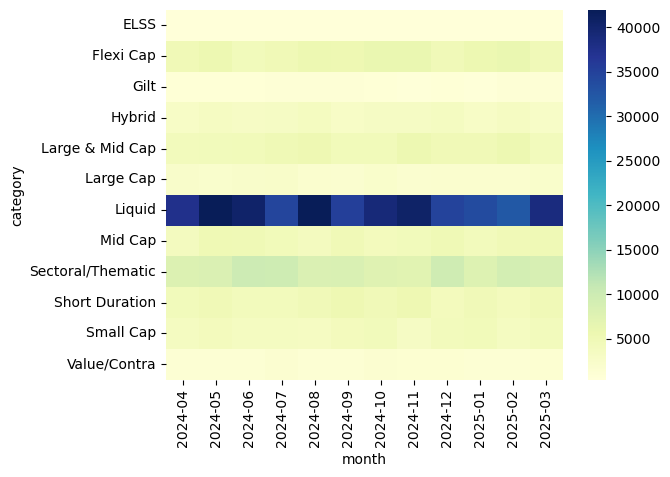

In [20]:
heatmap_data = category.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month'
)

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.show()

Observations:
Equity-oriented categories attract the highest inflows.
Certain categories consistently receive investor attention across months.
Some categories experience intermittent outflows, reflecting changing market sentiment.
Investor preference shifts depending on market conditions.
Heatmap patterns reveal seasonal and cyclical investment behavior.

TASK 5: Investor Demographics

Chart 8

Age Group Pie Chart

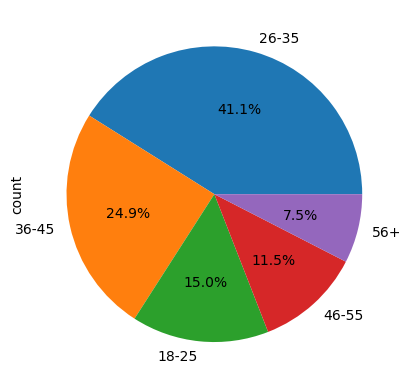

In [21]:
transactions['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

Observations:
The majority of investors belong to the young and middle-age segments.
Investors aged 26–35 contribute a significant share of transactions.
Participation decreases among older age groups.
Younger investors are increasingly adopting mutual funds for long-term wealth creation.
The industry is attracting a broad demographic base.

Chart 9

Gender Distribution

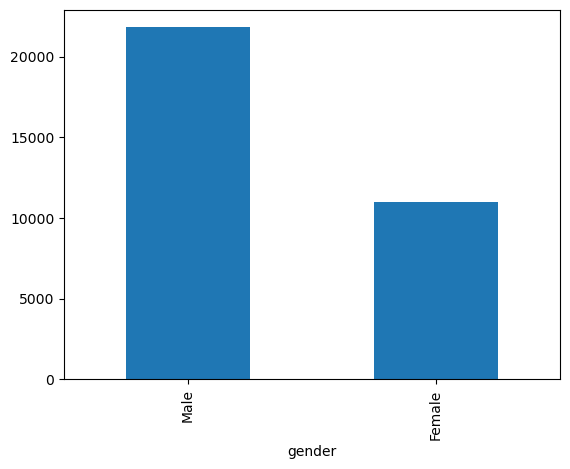

In [22]:
transactions['gender'].value_counts().plot(
    kind='bar'
)

plt.show()

Observations:
Male investors account for a larger proportion of transactions.
Female participation remains significant and continues to grow.
The gender gap presents opportunities for targeted financial inclusion initiatives.
Both genders actively participate in mutual fund investing.
Investor diversity contributes to market expansion.

Chart 10

Age vs Investment

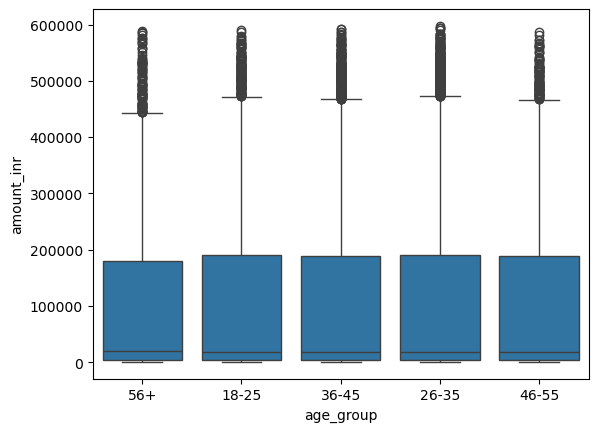

In [23]:
sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)

plt.show()

Observations:
Investment amounts vary significantly across age groups.
Middle-aged investors tend to invest larger amounts.
Younger investors participate more frequently but with smaller ticket sizes.
Some age groups exhibit greater variability in investment behavior.
Income levels likely influence investment capacity.

TASK 6: Geographic Distribution

Chart 11

State-wise Investment

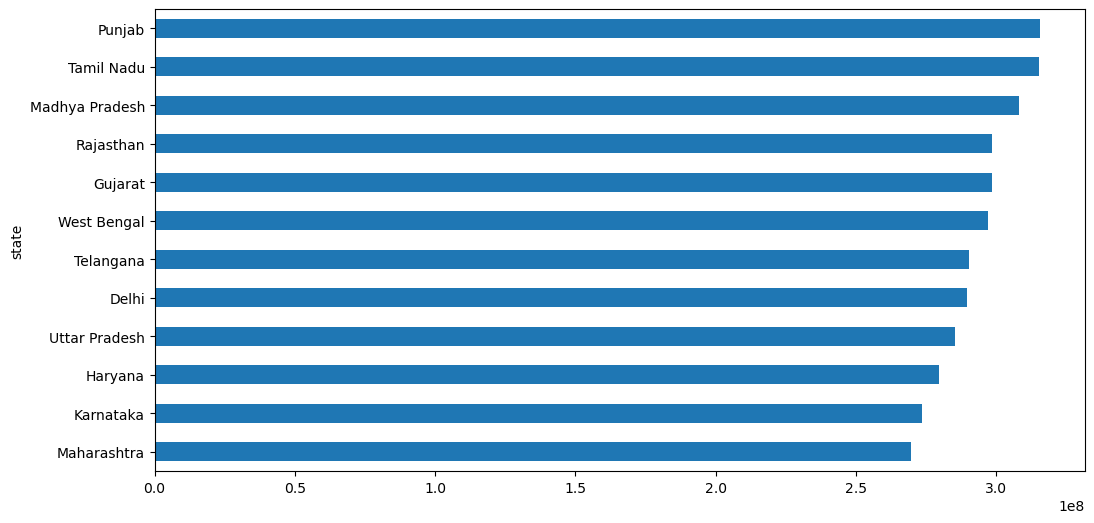

In [24]:
transactions.groupby(
    'state'
)['amount_inr'].sum().sort_values().plot(
    kind='barh',
    figsize=(12,6)
)

plt.show()

Observations:
Investment activity is concentrated in a few states.
Economically developed states contribute a major share of transaction volume.
Significant regional disparities exist in mutual fund participation.
Several states remain underpenetrated markets.
Geographic diversification offers future growth opportunities for AMCs.

Chart 12

T30 vs B30

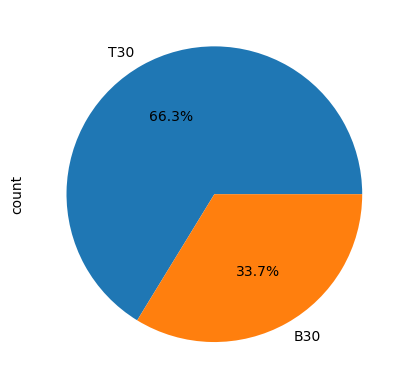

In [25]:
transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

Observations:
T30 cities contribute the majority of investments.
B30 participation is increasing but remains comparatively lower.
Urban investors continue to dominate mutual fund adoption.
Expansion into B30 markets presents substantial growth potential.
Financial awareness initiatives may improve B30 participation.

TASK 7: Folio Count Growth

Chart 13: Folio Count Growth

<Figure size 1200x500 with 0 Axes>

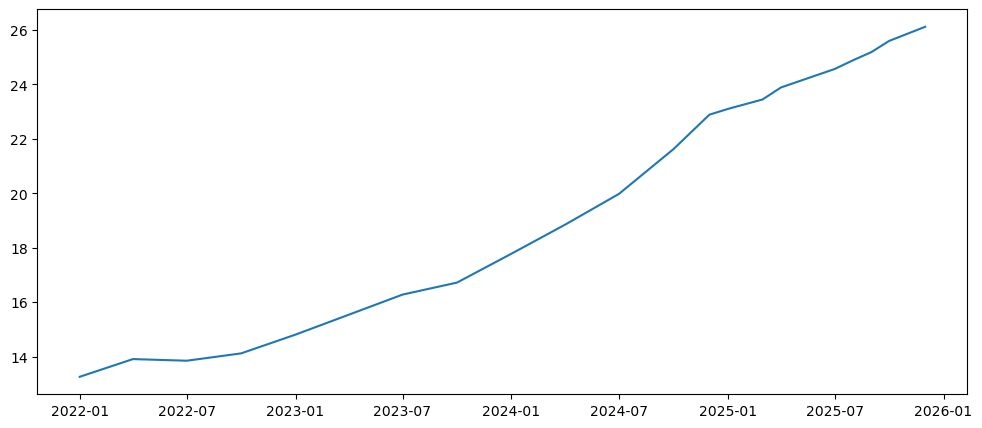

In [27]:
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12,5))
plt.plot(folio['month'], folio['total_folios_crore'])
plt.show()

Observations:
Folio counts have increased steadily over the study period.
Growth indicates expanding investor participation in mutual funds.
Investor onboarding accelerated in recent years.
Rising folio counts support industry-wide AUM growth.
The mutual fund industry continues to broaden its investor base.

TASK 8: Correlation Matrix

Chart 14: Correlation Matrix

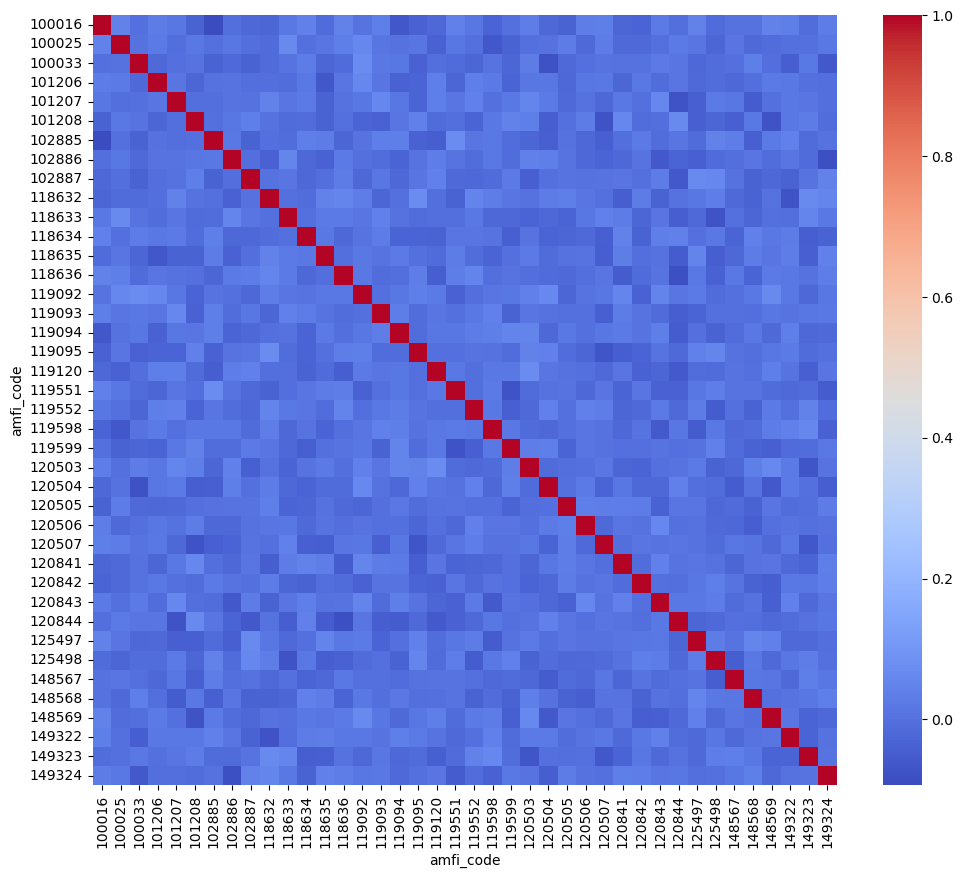

In [28]:
pivot_nav = nav.pivot_table(
    values='nav',
    index='date',
    columns='amfi_code'
)

returns = pivot_nav.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.show()

Observations:
Most large-cap funds exhibit strong positive correlations.
Funds within the same category tend to move together.
Some funds show relatively lower correlation, offering diversification benefits.
High correlations reflect common exposure to market-wide factors.
Diversification opportunities may exist across different fund categories.

TASK 9: Sector Allocation

Chart 15: Sector Allocation Pie Chart

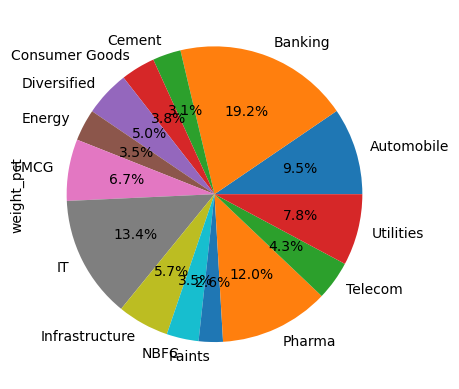

In [29]:
portfolio.groupby(
    'sector'
)['weight_pct'].sum().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

Observations:
Portfolio exposure is concentrated in a few key sectors.
Financial and technology sectors often represent significant allocations.
Sector concentration can influence portfolio risk.
Diversification across sectors reduces dependence on a single industry.
Sector allocation reflects prevailing market opportunities.

Chart 16

Sector Bar Chart

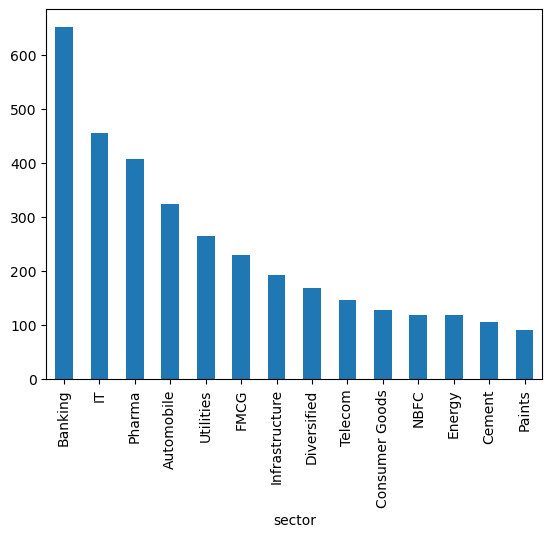

In [32]:
portfolio.groupby(
    'sector'
)['weight_pct'].sum().sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.show()

Observations:
Certain sectors receive substantially higher allocations than others.
Portfolio managers show strong conviction in leading sectors.
Lower-weight sectors contribute less to overall portfolio performance.
Sector preferences align with broader market trends.
Sector concentration should be monitored as part of risk management.

# Key Findings

1. Mutual fund NAVs show long-term growth.
2. 2023 experienced strong NAV appreciation.
3. SBI Mutual Fund leads in AUM.
4. SIP inflows steadily increased.
5. Active SIP accounts grew significantly.
6. Equity categories attracted higher inflows.
7. Investors aged 26–35 contribute most transactions.
8. T30 cities contribute a larger investment share.
9. Technology and Financial sectors dominate holdings.
10. Most large-cap funds show strong positive correlation.